<a href="https://colab.research.google.com/github/w1t1ta/Project_01/blob/main/test_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 29.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.4 which is incompatible.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 2.2.4 which is incompatible.


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet101_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/deeplabv3_resnet101_coco-586e9e4e.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet101_coco-586e9e4e.pth
100%|██████████| 233M/233M [00:01<00:00, 146MB/s]


Original Image Size: (828, 1104)
Original Image Size: (828, 1104)


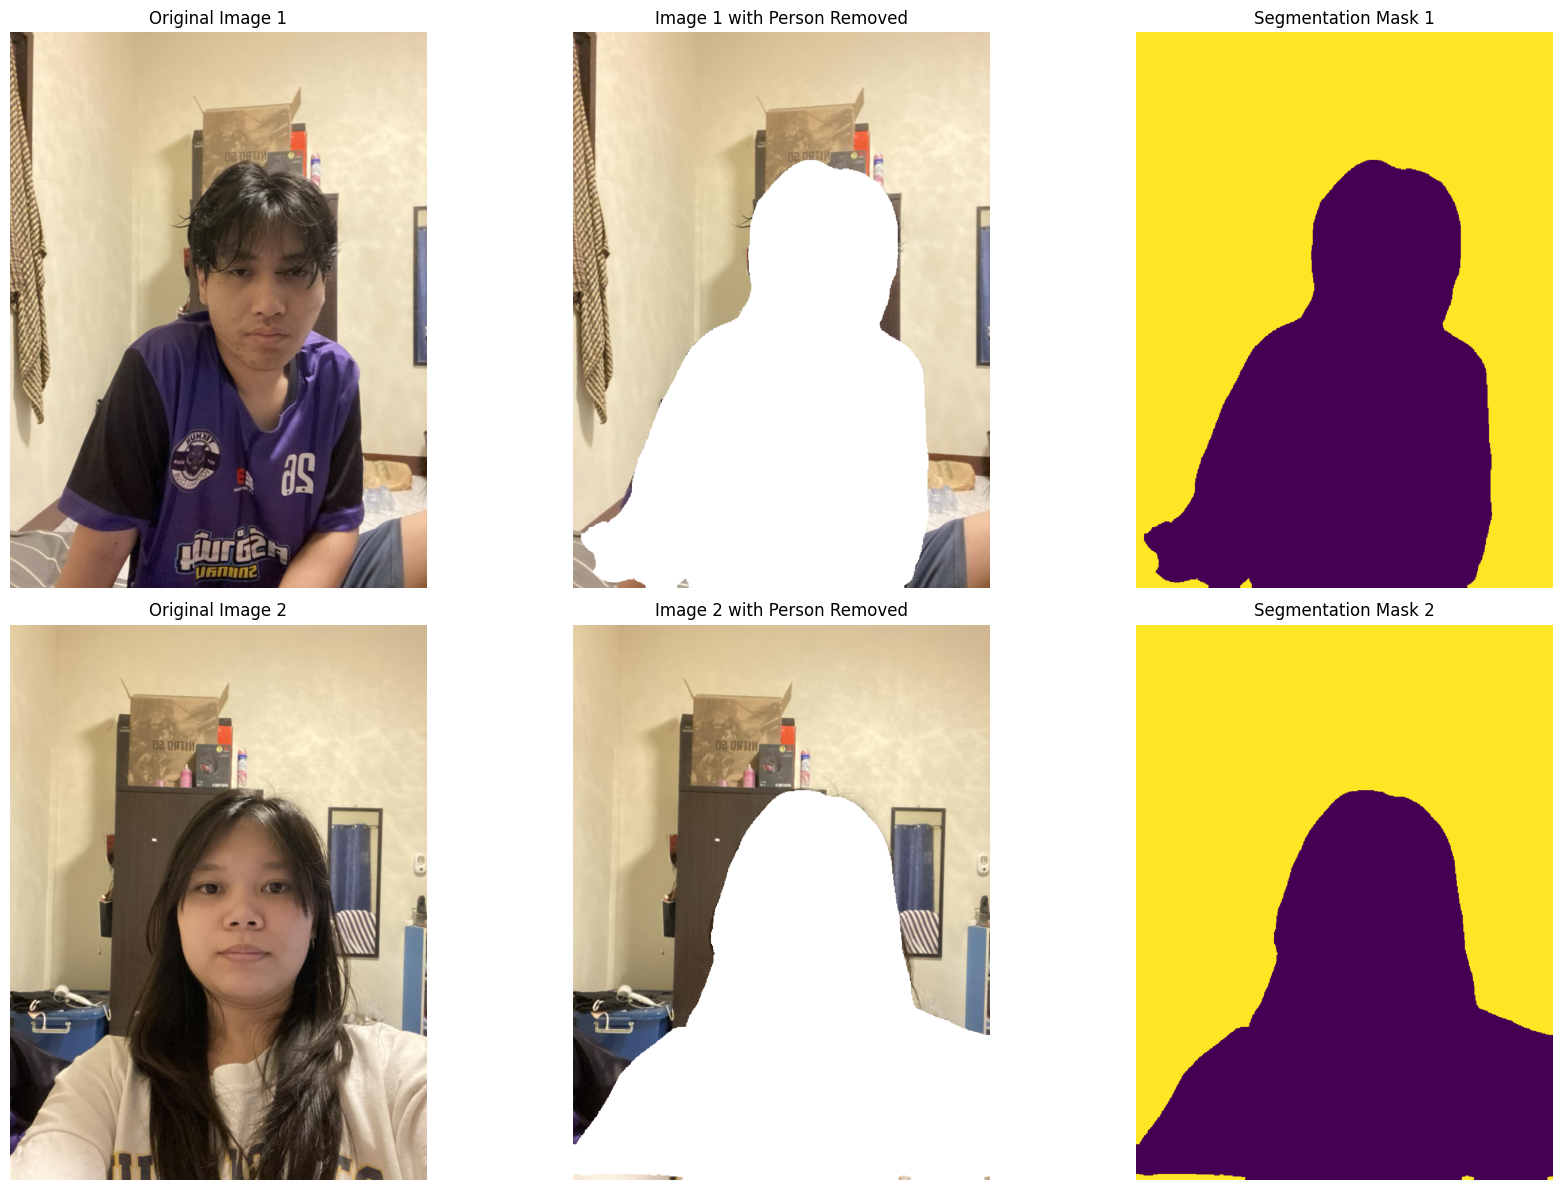

Images have been saved to the 'output' folder.


In [1]:
!pip install opencv-python
!pip install numpy --force-reinstall --quiet

import torch
import torchvision.transforms as T
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import os
from torchvision import models
import cv2

# โหลดโมเดล DeepLabV3+ ที่พรีเทรนแล้ว
model = models.segmentation.deeplabv3_resnet101(pretrained=True)
model.eval()  # ตั้งโมเดลเป็นโหมดทำนาย

# โหลดภาพที่ต้องการทดสอบ
image_path1 = '/content/484306100_1607547476614172_7718928177540118125_n.jpg'  # กำหนดเส้นทางภาพที่ต้องการทดสอบ 1
image_path2 = '/content/484780875_954835580188785_170552539904722165_n.jpg'  # กำหนดเส้นทางภาพที่ต้องการทดสอบ 2

# ฟังก์ชันในการประมวลผลภาพ
def process_image(image_path):
    image = Image.open(image_path)

    # ตรวจสอบขนาดของภาพก่อนทำการแปลง
    print(f"Original Image Size: {image.size}")

    # แปลงภาพจาก PIL เป็น Tensor สำหรับโมเดล
    transform = T.Compose([T.Resize(520), T.ToTensor()])
    input_image = transform(image).unsqueeze(0)  # แปลงเป็น tensor และเพิ่ม batch dimension

    # ทำนายผลลัพธ์
    with torch.no_grad():
        output = model(input_image)['out'][0]  # นำผลลัพธ์จากโมเดล
    output_predictions = output.argmax(0)  # ใช้ argmax เพื่อหา class ที่สูงที่สุด

    # สร้าง mask เพื่อหาพื้นหลัง
    person_mask = output_predictions != 15  # 15 คือตัวเลขของบุคคลใน DeepLabV3+

    # แปลง person_mask เป็น NumPy array
    person_mask_np = person_mask.cpu().numpy()

    # Resize the mask to the original image size
    person_mask_np = cv2.resize(person_mask_np.astype(np.uint8), (image.width, image.height), interpolation=cv2.INTER_NEAREST)

    # แปลงภาพเป็น numpy array
    image_array = np.array(image)

    # สร้างภาพใหม่ที่ลบบุคคลออกจากภาพ (โดยการใช้ mask)
    image_with_no_person = np.dstack([image_array, person_mask_np * 255])

    # แปลงกลับเป็นภาพ PIL
    result_image = Image.fromarray(image_with_no_person)

    return image, result_image, person_mask_np

# ประมวลผลภาพทั้งสอง
image1, result_image1, mask1 = process_image(image_path1)
image2, result_image2, mask2 = process_image(image_path2)

# แสดงภาพทั้งสอง
fig, axarr = plt.subplots(2, 3, figsize=(18, 12))

# แสดงภาพต้นฉบับและผลลัพธ์สำหรับภาพแรก
axarr[0, 0].imshow(image1)
axarr[0, 0].set_title('Original Image 1')
axarr[0, 0].axis('off')

axarr[0, 1].imshow(result_image1)
axarr[0, 1].set_title('Image 1 with Person Removed')
axarr[0, 1].axis('off')

axarr[0, 2].imshow(Image.fromarray(mask1.astype(np.uint8) * 255))
axarr[0, 2].set_title('Segmentation Mask 1')
axarr[0, 2].axis('off')

# แสดงภาพต้นฉบับและผลลัพธ์สำหรับภาพที่สอง
axarr[1, 0].imshow(image2)
axarr[1, 0].set_title('Original Image 2')
axarr[1, 0].axis('off')

axarr[1, 1].imshow(result_image2)
axarr[1, 1].set_title('Image 2 with Person Removed')
axarr[1, 1].axis('off')

axarr[1, 2].imshow(Image.fromarray(mask2.astype(np.uint8) * 255))
axarr[1, 2].set_title('Segmentation Mask 2')
axarr[1, 2].axis('off')

plt.tight_layout()
plt.show()

# บันทึกผลลัพธ์ลงในโฟลเดอร์ 'output'
output_folder = 'output'
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

# บันทึกภาพต้นฉบับ
image1.save(os.path.join(output_folder, 'original_image1.jpg'))
image2.save(os.path.join(output_folder, 'original_image2.jpg'))

# บันทึกภาพผลลัพธ์
result_image1.save(os.path.join(output_folder, 'image1_with_person_removed.png'))
result_image2.save(os.path.join(output_folder, 'image2_with_person_removed.png'))

# บันทึก segmentation mask
Image.fromarray(mask1.astype(np.uint8) * 255).save(os.path.join(output_folder, 'segmentation_mask1.png'))
Image.fromarray(mask2.astype(np.uint8) * 255).save(os.path.join(output_folder, 'segmentation_mask2.png'))

print("Images have been saved to the 'output' folder.")


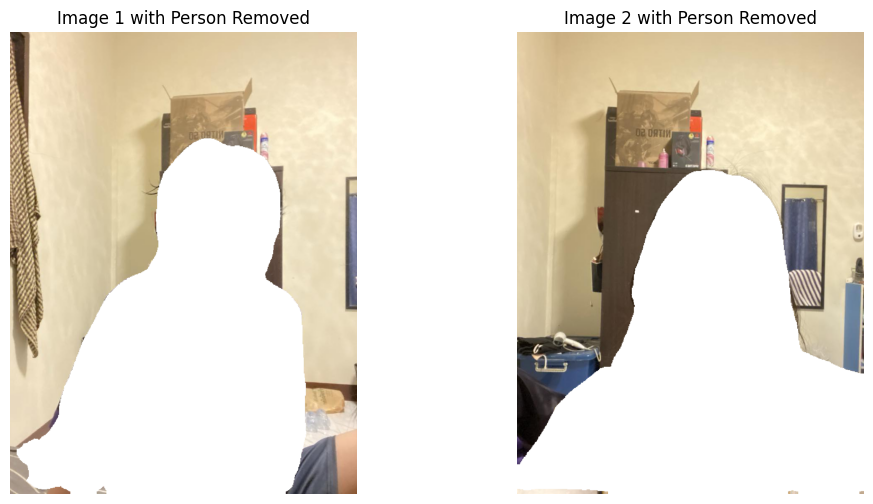

In [2]:
import matplotlib.pyplot as plt
from PIL import Image

# โหลดภาพจาก path ที่บันทึกไว้
image_path1 = "/content/output/image1_with_person_removed.png"
image_path2 = "/content/output/image2_with_person_removed.png"

image1 = Image.open(image_path1)
image2 = Image.open(image_path2)

# แสดงภาพ
fig, axarr = plt.subplots(1, 2, figsize=(12, 6))

# แสดงภาพแรก
axarr[0].imshow(image1)
axarr[0].set_title("Image 1 with Person Removed")
axarr[0].axis("off")

# แสดงภาพที่สอง
axarr[1].imshow(image2)
axarr[1].set_title("Image 2 with Person Removed")
axarr[1].axis("off")

plt.show()

In [3]:
# ติดตั้งเฉพาะที่จำเป็นและไม่มี conflict
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118 --quiet
!pip install git+https://github.com/openai/CLIP.git --quiet
!pip install transformers huggingface_hub --quiet
!pip install numpy==1.24.4 --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 74.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 40.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 82.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.9/663.9 MB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.9/417.9 MB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 7.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 MB 18.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.2/128.2 MB 7.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.1/204.1 MB 6.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 MB 7.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.7/848.7 MB 740.7 kB/s eta 0:00:00
  Preparing metadata

In [5]:
import torch
from PIL import Image
from torchvision import transforms
import clip
from transformers import AutoProcessor, AutoModel

device = "cuda" if torch.cuda.is_available() else "cpu"

RuntimeError: Failed to import transformers.models.auto.processing_auto because of the following error (look up to see its traceback):
Failed to import transformers.generation.utils because of the following error (look up to see its traceback):
No module named 'numpy.char'

In [ ]:
# === 1. CLIP ===
def get_clip_similarity(img1_path, img2_path):
    model, preprocess = clip.load("ViT-B/32", device=device)
    img1 = preprocess(Image.open(img1_path)).unsqueeze(0).to(device)
    img2 = preprocess(Image.open(img2_path)).unsqueeze(0).to(device)
    with torch.no_grad():
        f1 = model.encode_image(img1)
        f2 = model.encode_image(img2)
    return torch.cosine_similarity(f1, f2).item()

# === 2. ReVA ===
def get_reva_similarity(img1_path, img2_path):
    processor = AutoProcessor.from_pretrained("NAVER/reva-clip-vit-base-patch32")
    model = AutoModel.from_pretrained("NAVER/reva-clip-vit-base-patch32").to(device)
    images = [Image.open(img1_path).convert("RGB"), Image.open(img2_path).convert("RGB")]
    inputs = processor(images=images, return_tensors="pt").to(device)
    with torch.no_grad():
        image_features = model.get_image_features(**inputs)
    return torch.cosine_similarity(image_features[0].unsqueeze(0), image_features[1].unsqueeze(0)).item()

In [ ]:
# ✅ Step 4: Set image paths and run comparisons

img_path1 = "/content/output/image1_with_person_removed.png"
img_path2 = "/content/output/image2_with_person_removed.png"

print("CLIP similarity:", get_clip_similarity(img_path1, img_path2))
print("ReVA similarity:", get_reva_similarity(img_path1, img_path2))